## Understand H5 formats

In [14]:
import h5py
from scipy.sparse import csr_matrix
import numpy as np
f = h5py.File('data/fiqa-dev.h5', 'r')

14498188 14498411


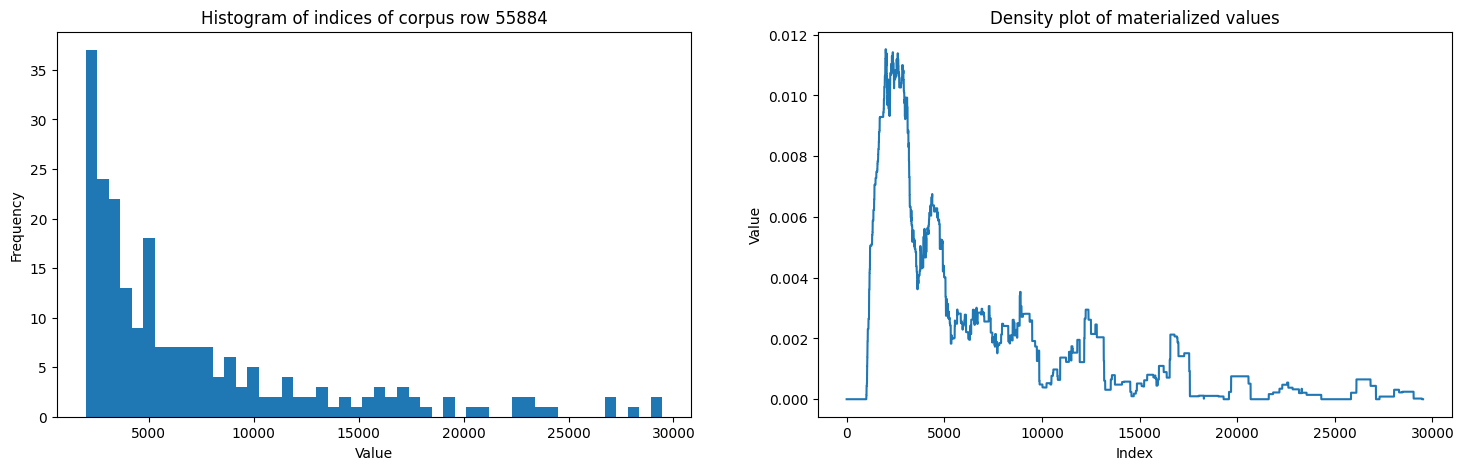

In [261]:
ft = h5py.File('data/fiqa-dev.h5', 'r')
indptr = ft['train']['indptr']

row_i = np.random.randint(0, 57638)
row_i = 55884
print(indptr[row_i], indptr[row_i + 1])

start = indptr[row_i]
end = indptr[row_i + 1]

d = ft['train']['indices'][start:end]
# sort array d
d.sort()

# make a histogram of the values in d
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(18, 5))
ax[0].hist(d, bins=50)
ax[0].set_title(f'Histogram of indices of corpus row {row_i}')
ax[0].set_xlabel('Value')
ax[0].set_ylabel('Frequency')

data = ft['train']['data'][start:end]

materialize_values = np.zeros(ft['train'].attrs['shape'][1])
# place value in appropriate place in materialize_values
for i in range(len(d)):
    materialize_values[d[i]] = data[i]

# normalize (divide by max value)
materialize_values /= materialize_values.max()

# perform a smooth average with a window of 10
window_size = 1000
smoothed_values = np.convolve(materialize_values, np.ones(window_size)/window_size, mode='valid')

# plot a density plot of materialize_values
ax[1].plot(smoothed_values)
ax[1].set_title('Density plot of materialized values')
ax[1].set_xlabel('Index')
ax[1].set_ylabel('Value')

plt.show()

In [172]:
row_i = 2461

43028 43073


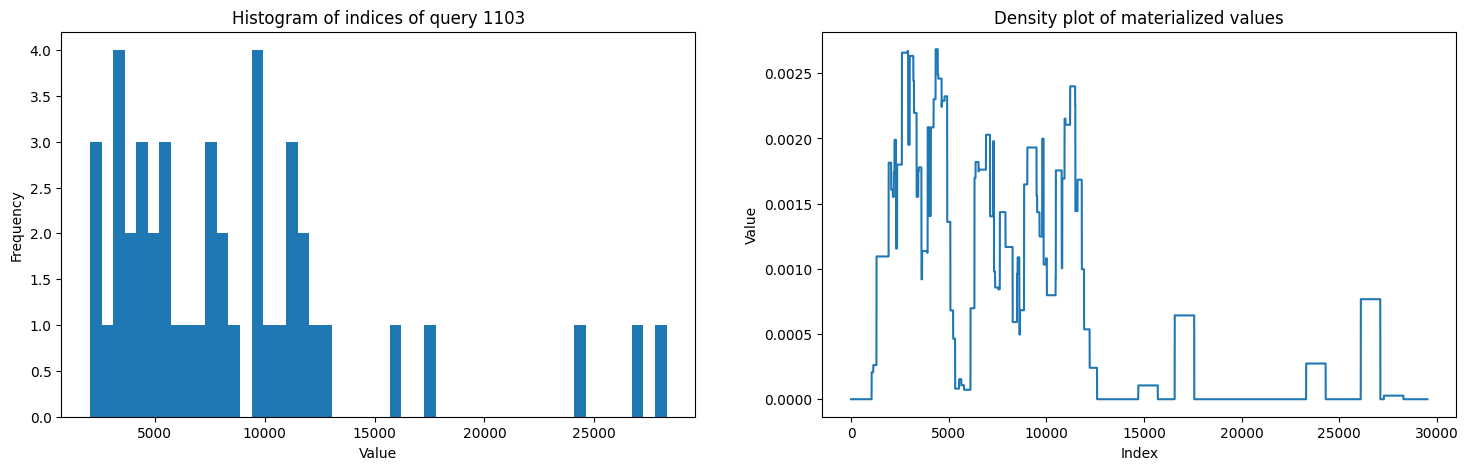

In [257]:
fq = h5py.File('data/fiqa-dev.h5', 'r')
indptr = fq['otest/queries']['indptr']

row_i = np.random.randint(0, 6000)
print(indptr[row_i], indptr[row_i + 1])

start = indptr[row_i]
end = indptr[row_i + 1]

d = fq['otest/queries']['indices'][start:end]
# sort array d
d.sort()

# make a histogram of the values in d
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(18, 5))
ax[0].hist(d, bins=50)
ax[0].set_title(f'Histogram of indices of query {row_i}')
ax[0].set_xlabel('Value')
ax[0].set_ylabel('Frequency')

data = fq['otest/queries']['data'][start:end]

materialize_values = np.zeros(fq['otest/queries'].attrs['shape'][1])
# place value in appropriate place in materialize_values
for i in range(len(d)):
    materialize_values[d[i]] = data[i]

# normalize (divide by max value)
materialize_values /= materialize_values.max()

# perform a smooth average with a window of 10
window_size = 1000
smoothed_values = np.convolve(materialize_values, np.ones(window_size)/window_size, mode='valid')

# plot a density plot of materialize_values
ax[1].plot(smoothed_values)
ax[1].set_title('Density plot of materialized values')
ax[1].set_xlabel('Index')
ax[1].set_ylabel('Value')

plt.show()

In [224]:
answers_freq = {}

## Run Naive and Verify Resuts

In [258]:
import timeit
import h5py
import numpy as np

from scipy.sparse import csr_matrix
def load_sparse_matrix(h5_group):
    print(f"Loading sparse matrix from group: {h5_group.name}")
    print(f"Shape attribute: {h5_group.attrs['shape']}")
    indptr = h5_group['indptr'][:]
    indices = h5_group['indices'][:]
    data = h5_group['data'][:]
    shape = tuple(h5_group.attrs['shape'])
    return csr_matrix((data, indices, indptr), shape=shape)

with h5py.File('data/fiqa-dev.h5', 'r') as f:
    train_matrix = load_sparse_matrix(f["train"])
    queries = load_sparse_matrix(f["otest/queries"])
    print(f"Train matrix shape: {train_matrix.shape}")
    print(f"Queries matrix shape: {queries.shape}")
# each query flattened to a dense vector, perform a dot product with all rows of the matrix and sort by value, get top 15 results
print("Computing dot products between queries and matrix rows")
results = []
for i in [row_i]:
    print(f"Processing query {i}/{queries.shape[0]}")
    start_time = timeit.default_timer()
    query = queries[i]
    scores = (train_matrix @ query.T).toarray().flatten()
    top_indices = np.argpartition(scores, -30)[-30:]
    
    top_indices = top_indices[np.argsort(scores[top_indices])[::-1]]

    results.append(list(zip(top_indices.tolist(), scores[top_indices].tolist())))
    end_time = timeit.default_timer()
    print(f"Time taken: {end_time - start_time} seconds")

# results is an array of of array of touples (rowId, score). We know the first array only has 1 element and then 30 touples.
# for each touple add its rowId to the answers_freq dictionary if not already there and add 1 to its value
for result in results:
    for rowId, score in result:
        if rowId not in answers_freq:
            answers_freq[rowId] = 0
        answers_freq[rowId] += 1

results

Loading sparse matrix from group: /train
Shape attribute: [57638 30522]
Loading sparse matrix from group: /otest/queries
Shape attribute: [ 6648 30522]
Train matrix shape: (57638, 30522)
Queries matrix shape: (6648, 30522)
Computing dot products between queries and matrix rows
Processing query 1103/6648
Time taken: 0.022493666998343542 seconds


[[(55884, 22.047727584838867),
  (8263, 21.872390747070312),
  (43831, 21.505924224853516),
  (26914, 21.310142517089844),
  (28555, 21.0412654876709),
  (13475, 20.601512908935547),
  (8229, 20.222257614135742),
  (16046, 19.95745277404785),
  (4946, 19.912078857421875),
  (491, 19.893083572387695),
  (33970, 19.718158721923828),
  (12048, 19.70743751525879),
  (9100, 19.306549072265625),
  (51146, 19.11711883544922),
  (28932, 19.108240127563477),
  (26055, 19.016021728515625),
  (16432, 19.00154685974121),
  (49653, 18.92371940612793),
  (28041, 18.913040161132812),
  (23783, 18.864028930664062),
  (47403, 18.645357131958008),
  (31298, 18.61263656616211),
  (9744, 18.546701431274414),
  (50949, 18.5262393951416),
  (26496, 18.48735809326172),
  (48725, 18.424022674560547),
  (43884, 18.4234619140625),
  (31859, 18.40692138671875),
  (41113, 18.39950180053711),
  (21605, 18.398847579956055)]]

In [259]:
# sort answers_freq by value
sorted_answers_freq = dict(sorted(answers_freq.items(), key=lambda item: item[1], reverse=True))
sorted_answers_freq

{46817: 2,
 25358: 1,
 15565: 1,
 5074: 1,
 9859: 1,
 38085: 1,
 54369: 1,
 37732: 1,
 28177: 1,
 28447: 1,
 4641: 1,
 19555: 1,
 24129: 1,
 45837: 1,
 25061: 1,
 45176: 1,
 29191: 1,
 49154: 1,
 17136: 1,
 5489: 1,
 29236: 1,
 46782: 1,
 24878: 1,
 7805: 1,
 24936: 1,
 50785: 1,
 13298: 1,
 11552: 1,
 44796: 1,
 42353: 1,
 49181: 1,
 32334: 1,
 49062: 1,
 24986: 1,
 14683: 1,
 9665: 1,
 54711: 1,
 27047: 1,
 751: 1,
 48862: 1,
 45245: 1,
 2937: 1,
 25910: 1,
 56772: 1,
 49785: 1,
 40877: 1,
 42699: 1,
 8445: 1,
 37730: 1,
 34063: 1,
 10334: 1,
 44639: 1,
 18575: 1,
 42311: 1,
 12451: 1,
 55815: 1,
 53003: 1,
 33038: 1,
 4392: 1,
 47371: 1,
 34169: 1,
 47196: 1,
 14323: 1,
 36506: 1,
 31255: 1,
 55087: 1,
 43774: 1,
 11269: 1,
 12368: 1,
 55554: 1,
 44253: 1,
 54124: 1,
 34194: 1,
 44886: 1,
 51734: 1,
 5232: 1,
 56055: 1,
 38132: 1,
 29909: 1,
 42305: 1,
 22723: 1,
 4832: 1,
 22892: 1,
 37590: 1,
 8278: 1,
 17448: 1,
 19727: 1,
 20494: 1,
 34427: 1,
 14645: 1,
 31856: 1,
 19016: 1,
 5

In [54]:
q0_closest = [r[0] for r in results[0]]

print(f"Query q has {queries[0].nnz} non-zero indices")
for v in q0_closest:
    number_of_shared_nonzeros = len(set(train_matrix[v].nonzero()[1]) & set(queries[0].nonzero()[1]))
    print(f"Row {v} has {number_of_shared_nonzeros} shared non-zero indices with the query")

Query q has 30 non-zero indices
Row 1800 has 21 shared non-zero indices with the query
Row 20778 has 20 shared non-zero indices with the query
Row 20347 has 23 shared non-zero indices with the query
Row 40146 has 20 shared non-zero indices with the query
Row 51106 has 19 shared non-zero indices with the query
Row 18578 has 20 shared non-zero indices with the query
Row 51967 has 22 shared non-zero indices with the query
Row 5293 has 19 shared non-zero indices with the query
Row 31657 has 17 shared non-zero indices with the query
Row 54067 has 19 shared non-zero indices with the query
Row 7277 has 24 shared non-zero indices with the query
Row 27421 has 19 shared non-zero indices with the query
Row 7424 has 21 shared non-zero indices with the query
Row 18727 has 22 shared non-zero indices with the query
Row 40455 has 19 shared non-zero indices with the query
Row 39441 has 17 shared non-zero indices with the query
Row 46528 has 17 shared non-zero indices with the query
Row 32732 has 16 sha

## Analyze Naive Time Complexity and Estimate Times

In [19]:

import h5py
import timeit
import numpy as np
from scipy.sparse import csr_matrix
# with h5py.File('data/query2_nq.h5', 'r') as query_file:
#     query_group = query_file['otest/queries']
#     with h5py.File('data/nq.h5', 'r') as train_file:
#         train_group = train_file['train']

#         with h5py.File('data/nq_wq.h5', 'w') as f:
#             # copy train group
#             f.copy(train_group, 'train')
#             # copy query group
#             f.copy(query_group, 'otest/queries')

def load_sparse_matrix(h5_group):
    print(f"Loading sparse matrix from group: {h5_group.name}")
    print(f"Shape attribute: {h5_group.attrs['shape']}")
    indptr = h5_group['indptr'][:]
    indices = h5_group['indices'][:]
    data = h5_group['data'][:]
    shape = tuple(h5_group.attrs['shape'])
    return csr_matrix((data, indices, indptr), shape=shape)

def get_random_reduced_matrix(matrix, n):
    # get n random rows from the matrix
    random_indices = np.random.choice(matrix.shape[0], n, replace=False)
    return matrix[random_indices]

def make_runner():
    with h5py.File('data/nq_wq.h5', 'r') as f:
        train_matrix = load_sparse_matrix(f['train'])
        queries_matrix = load_sparse_matrix(f['otest/queries'])

# each query flattened to a dense vector, perform a dot product with all rows of the matrix and sort by value, get top 15 results
# print(f"Queries matrix shape: {queries_matrix.shape}")
# print("Computing dot products between queries and matrix rows")


    def run_similarity_search(n):
        _train_matrix = get_random_reduced_matrix(train_matrix, n)
        _queries_matrix = get_random_reduced_matrix(queries_matrix, 1000)

        num_queries = _queries_matrix.shape[0]
        start_time = timeit.default_timer()
        results = []
        for i in range(num_queries):
            # print(f"Processing query {i}/{_queries_matrix.shape[0]}")
            query = _queries_matrix[i]
            scores = (_train_matrix @ query.T).toarray().flatten()
            top_indices = np.argpartition(scores, -30)[-30:]
            
            top_indices = top_indices[np.argsort(scores[top_indices])[::-1]]

            results.append(list(zip(top_indices.tolist(), scores[top_indices].tolist())))
            # print(f"Time taken: {end_time - start_time} seconds")
        end_time = timeit.default_timer()

        duration = end_time - start_time
        duration_per_query = (duration / (num_queries / 1000)) # every 1000 queries
        print(f"Total time taken: {duration} seconds. Time per 1000 queries: {duration_per_query} seconds")
        return duration_per_query
    
    def run_similarity_search_without_np(n):
        _train_matrix = get_random_reduced_matrix(train_matrix, n)
        _queries_matrix = get_random_reduced_matrix(queries_matrix, 1000)

        num_queries = _queries_matrix.shape[0]
        start_time = timeit.default_timer()
        results = []
        scores = np.zeros(_train_matrix.shape[0])
        for i in range(num_queries):
            # print(f"Processing query {i}/{_queries_matrix.shape[0]}")
            query = _queries_matrix[i]
            for j in range(_train_matrix.shape[0]):
                score = query.dot(_train_matrix[j].T).toarray()[0][0]
                scores[j] = score
            top_indices = np.argpartition(scores, -30)[-30:]
            top_indices = top_indices[np.argsort(scores[top_indices])[::-1]]
            results.append(list(zip(top_indices.tolist(), scores[top_indices].tolist())))
            # print(f"Time taken: {end_time - start_time} seconds")


        end_time = timeit.default_timer()

        duration = end_time - start_time
        duration_per_query = (duration / (num_queries / 1000)) # every 1000 queries
        print(f"Total time taken: {duration} seconds. Time per 1000 queries: {duration_per_query} seconds")

    return run_similarity_search_without_np

# def run_similarity_search(n):
#     # sparse matrix train
#     # all queries??? which query... fuck
#     pass




# import h5py
# with h5py.File('data/nq.h5', 'r') as f:
#     queries_matrix = load_sparse_matrix(f['otest/queries'])

# # average number of nnz in each query
# average_nnz = queries_matrix.nnz / queries_matrix.shape[0]
# print(f"Average number of non-zero elements per query: {average_nnz}")
# # min and max number of a nnz in all queries
# min_nnz = min(len(queries_matrix[i].nonzero()[1]) for i in range(queries_matrix.shape[0]))
# max_nnz = max(len(queries_matrix[i].nonzero()[1]) for i in range(queries_matrix.shape[0]))
# print(f"Minimum number of non-zero elements in a query: {min_nnz}")
# print(f"Maximum number of non-zero elements in a query: {max_nnz}")

In [20]:
import datetime
import time
import pandas as pd

MIN=10_000
MAX=100_000
DELTA = 10_000

run_similarity_search = make_runner()

# data is run, program (brute force), dataset (nq300k for now), problem size, time taken (secs)
df = pd.DataFrame([], columns=["run", "program", "dataset", "problem_size", "time"])
for i, n in enumerate(range(MIN, MAX+1, DELTA)):
    print(f"Processing problem size {n}")
    now = datetime.datetime.now()
    # heavy computation here

    run_similarity_search(n)

    end = datetime.datetime.now()
    seconds_elapsed = (end - now).total_seconds()
    print(f"Time taken for problem size {n}: {seconds_elapsed} seconds")
    series = pd.Series({
        "run": i,
        "program": "brute-force",
        "dataset": "nq300k",
        "problem_size": n,
        "time[secs]": seconds_elapsed
    })
    # concat the series to the dataframe
    df = pd.concat([df, series.to_frame().T], ignore_index=True)
    df.to_csv("nq300k-bruteforce-times-3.csv", index=False)

df

Loading sparse matrix from group: /train
Shape attribute: [311520  30522]
Loading sparse matrix from group: /otest/queries
Shape attribute: [ 3452 30522]
Processing problem size 10000


KeyboardInterrupt: 

<Axes: title={'center': 'Brute-force similarity search time vs problem size'}, xlabel='problem_size', ylabel='Time (seconds) per 1k queries'>

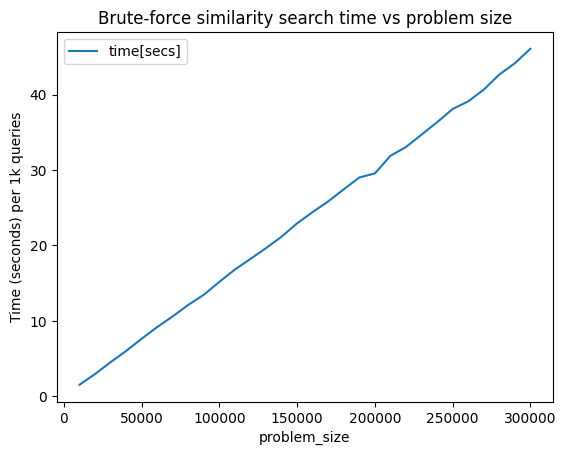

In [32]:
import pandas as pd
df = pd.read_csv("nq300k-bruteforce-times.csv")
df.plot(x="problem_size", y="time[secs]", kind="line", ylabel="Time (seconds) per 1k queries", title="Brute-force similarity search time vs problem size")

<Axes: title={'center': 'Brute-force similarity search time vs problem size'}, xlabel='problem_size', ylabel='Time (seconds) per 1k queries'>

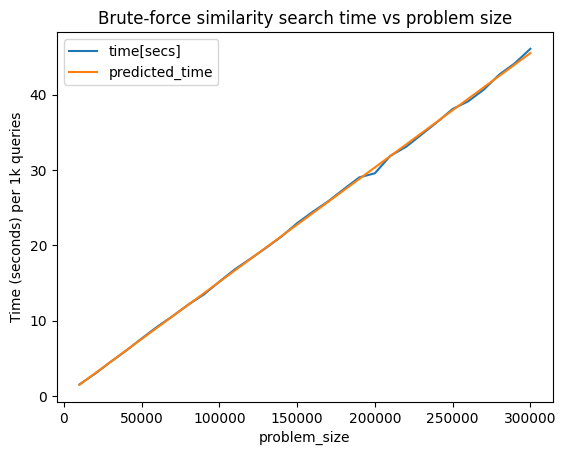

In [33]:
# linear regress a line
import numpy as np
from sklearn.linear_model import LinearRegression

X = df["problem_size"].values.reshape(-1, 1)
y = df["time[secs]"].values
model = LinearRegression()
model.fit(X, y)
predicted_time = model.predict(X)
df["predicted_time"] = predicted_time
df.plot(x="problem_size", y=["time[secs]", "predicted_time"], kind="line", ylabel="Time (seconds) per 1k queries", title="Brute-force similarity search time vs problem size")

In [35]:
# In final evaluation case,
# N = 2.5M
# Q = 3k
def write_prediction(N, Q):
    secs_per_1k_queries =model.predict([[N]])[0]
    print(f"For the {Q} queries of the challenge evaluation it takes a total amount of {secs_per_1k_queries * (Q / 1000)} seconds")
    print(f"which is {secs_per_1k_queries * (Q / 1000) / 3600} hours")

write_prediction(2_500_000, 3_000)

For the 3000 queries of the challenge evaluation it takes a total amount of 1138.5065537741934 seconds
which is 0.3162518204928315 hours


In [2]:
with h5py.File('data/nq_wq.h5', 'r') as f:
        train_matrix = load_sparse_matrix(f['train'])

Loading sparse matrix from group: /train
Shape attribute: [311520  30522]


In [15]:
class LinkedListNode:
    def __init__(self, value, next=None, prev=None):
        self.value = value
        self.next: LinkedListNode | None = next
        self.prev: LinkedListNode | None = prev


component_dict: dict[int, LinkedListNode] = {}
max_rows = 0
for i in range(train_matrix.shape[0]):
    # get row i indices of columns that are nnz
    nnz_indices = train_matrix[i].nonzero()[1]
    for idx in nnz_indices:
        if idx not in component_dict:
            component_dict[idx] = LinkedListNode(i)
            component_dict[idx].next = component_dict[idx]
            component_dict[idx].prev = component_dict[idx]
        else:
            # add i to the linked list of component_dict[idx]
            root = component_dict[idx]
            last_element = root.prev
            new_node = LinkedListNode(i, next=root, prev=last_element)
            last_element.next = new_node
            root.prev = new_node


In [ ]:
def 

1